## Theory

### First: What Is A Model?

Imagine:

You are trying to guess how many candies a kid will eat.

You notice:

Older kids eat more.

Boys sometimes eat more than girls.

Kids who like chocolate eat more.

A model is just:

A machine that learns rules from past examples to guess future answers.

That’s it.

### Linear Regression — Explained Like You’re 5

Imagine we draw a line through points.

Each dot = one game
X-axis = year
Y-axis = global sales

Linear regression tries to draw:

The best straight line through all the dots.

It does NOT memorize.
It draws one straight rule.

Formula:

sales = intercept + coefficient * year

Intercept

Where the line starts.

If intercept = 5
It means:

If year was 0, predicted sales would be 5.

(Not realistic, but mathematically needed.)

Coefficient

If coefficient = -0.02

It means:

For every 1 year increase, sales decrease by 0.02 million.

That’s it.

It is slope.


### What Is MSE?

MSE = Mean Squared Error.

Imagine:

Actual sales = 10
Predicted = 8

Error = 2

We square it:

2² = 4

We do this for all games.
Then average.

Big errors hurt more because of squaring.


### Why square?

Because we don’t want negative errors to cancel positive ones.

What Is R²?

Imagine:

You predict the same number for every game:
“Average sales.”

That’s the dumbest possible model.

R² asks:

How much better are we than that dumb average guess?

If:
R² = 0 → same as dumb guess
R² = 0.5 → 50% better
R² = 1 → perfect


### Random Forest — Like a Bunch of Little Decision Makers

Instead of drawing one line,
Random Forest builds many tiny decision trees.

A tree thinks like this:

IF platform = Wii:
    predict high sales
ELSE IF genre = Sports:
    predict medium sales
ELSE:
    predict low sales


That’s one tree.

Random Forest builds hundreds of trees.
Then averages their predictions.

Why better?

Because real life is not a straight line.



### LinearRegression() Parameters

When you write:

LinearRegression()


There are parameters inside.
Most important ones:

1. fit_intercept=True

If True:
Model learns the starting point (intercept).

If False:
Model forces line to go through 0.

Usually keep True.

2. positive=False

If True:
Forces coefficients to be positive only.

Why?

Maybe in business logic negative doesn’t make sense.


### RandomForestRegressor Parameters

This is where confusion usually starts.

Let’s break the important ones.

n_estimators

Number of trees.

If 10 → small forest
If 500 → big forest

More trees = more stable
But slower

Not automatically better.

max_depth

How deep each tree can grow.

Think of tree depth like:

Depth 1:
One decision.

Depth 5:
Many layered decisions.

If depth too big:
Tree memorizes training data.

That is called overfitting.

min_samples_split

Minimum number of samples needed to split a node.

If small:
Tree splits aggressively.

If large:
Tree splits conservatively.

Controls overfitting.

min_samples_leaf

Minimum samples allowed in final leaf.

If 1:
Tree can memorize individual games.

If 20:
Each leaf must represent at least 20 games.

Prevents overfitting.

random_state

Controls randomness.

If fixed:
You get same results every time.

If not:
Results slightly change each run.

Always set it while learning.


### What Is Overfitting?

Imagine:

You memorize every single past exam question.

You score 100 on practice test.

But fail real exam.

Why?

Because you memorized,
not learned patterns.

Overfitting = memorizing training data.

Why Train Score > Test Score?

Because:

Model sees training data.
Learns details.
But cannot generalize.

If train R² = 0.95
Test R² = 0.30

You memorized.


### Why Cross Validation?

Instead of splitting once,
we split 5 times.

We train on different parts.
Test on different parts.

Then average.

More stable.

Less luck-based.

What Is Bias vs Variance?

Bias:
Model too simple.
Cannot capture patterns.

Variance:
Model too complex.
Captures noise.

We want balance.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("../data/raw/vgsales.csv")

df.columns = df.columns.str.lower().str.replace(" ","_")
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

df = pd.get_dummies(df[["year","platform","genre","global_sales"]],
                    columns=["platform","genre"],
                    drop_first=True)

X = df.drop("global_sales", axis=1)
y = df["global_sales"]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Underfitting vs Overfitting

Linear Regression

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# r2 Train
train_r2_lr = r2_score(y_train, lr.predict(X_train))

# r2 test
test_r2_lr = r2_score(y_test, lr.predict(X_test))

train_r2_lr, test_r2_lr

# If both r2 aare low then underfitting

(0.06507003532021494, 0.020912840679026434)

## Random Forest (high complexity)

In [5]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

train_r2_rf = r2_score(y_train, rf.predict(X_train))
test_r2_rf = r2_score(y_test, rf.predict(X_test))

train_r2_rf, test_r2_rf

(0.25304524876789425, -0.05445760457457016)

## Visualize Overfitting

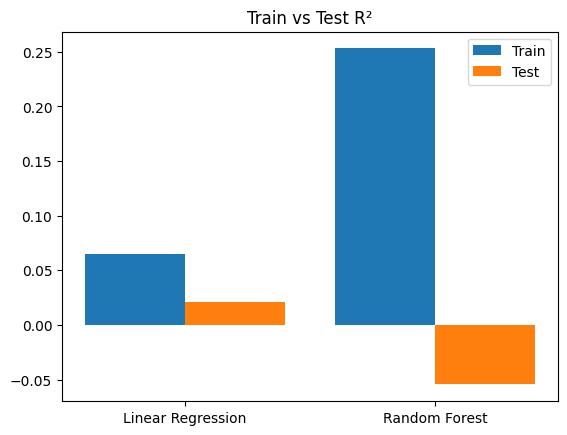

In [8]:
models = ["Linear Regression", "Random Forest"]
train_scores = [train_r2_lr, train_r2_rf]
test_scores = [test_r2_lr, test_r2_rf]

x = np.arange(len(models))

plt.bar(x - 0.2, train_scores, width=0.4, label="Train")
plt.bar(x + 0.2, test_scores, width=0.4, label="Test")
plt.xticks(x, models)
plt.legend()
plt.title("Train vs Test R²")
plt.show()

## Cross-Validation (The Real Score)

Train/test split depends on one random split.

Cross-validation reduces variance.

In [9]:
cv_scores_lr = cross_val_score(lr, X, y, cv=5, scoring="r2")
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring="r2")

cv_scores_lr.mean(), cv_scores_rf.mean()

(np.float64(-666.697723188621), np.float64(-906.9655647945132))

## Hyperparameter & Bias-Variance

Change complexity.

Small forest (high bias)

In [10]:
rf_small = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,
    random_state=42
)

rf_small.fit(X_train, y_train)

r2_score(y_test, rf_small.predict(X_test))

0.0017499870242316806

Deep forest (low bias, high variance)

In [11]:
rf_big = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

rf_big.fit(X_train, y_train)

r2_score(y_test, rf_big.predict(X_test))

-0.054457512845194955

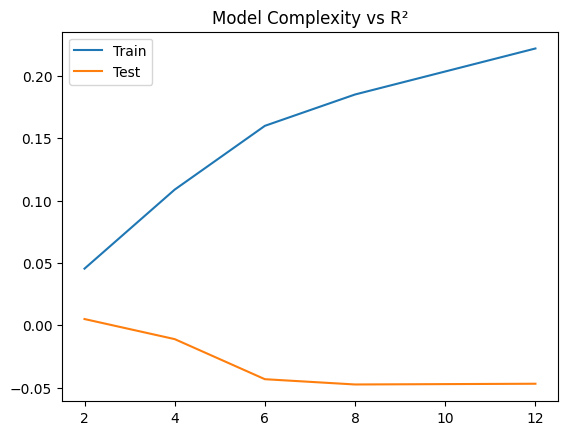

In [12]:
depths = [2, 4, 6, 8, 12, None]
train_scores = []
test_scores = []

for d in depths:
    model = RandomForestRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))

plt.plot(depths, train_scores, label="Train")
plt.plot(depths, test_scores, label="Test")
plt.legend()
plt.title("Model Complexity vs R²")
plt.show()